In [ ]:
from google.colab import files
uploaded = files.upload()


Saving HousingPrices-Amsterdam-August-2021.csv to HousingPrices-Amsterdam-August-2021.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

houseprices_data = pd.read_csv(
    "HousingPrices-Amsterdam-August-2021.csv",
    sep=',',            # Dấu phẩy là đúng
    encoding='utf-8-sig',
    index_col=0,        # Bỏ cột đầu tiên (số thứ tự)
    header=0            # Dòng đầu tiên là tên cột
)






In [ ]:


# 🔧 Làm sạch tên cột: loại bỏ dấu ngoặc kép và khoảng trắng dư
houseprices_data.columns = houseprices_data.columns.str.replace('"', '').str.replace(',', '').str.strip()

# Kiểm tra lại tên cột
print(houseprices_data.columns.tolist())

# Giữ lại 4 cột cần thiết
houseprices_data = houseprices_data[["Zip", "Price", "Area", "Room"]]

# Tạo biến mới: Giá mỗi mét vuông
houseprices_data['PriceperSqm'] = houseprices_data['Price'] / houseprices_data['Area']

# Hiển thị 5 dòng đầu
houseprices_data.head()


['Zip', 'Price', 'Area', 'Room', 'PriceperSqm']


,Zip,Price,Area,Room,PriceperSqm
1,1091 CR,685000.0,64,3,10703.125000
2,1059 EL,475000.0,60,3,7916.666667
3,1097 SM,850000.0,109,4,7798.165138
4,1060 TH,580000.0,128,6,4531.250000
5,1036 KN,720000.0,138,5,5217.391304


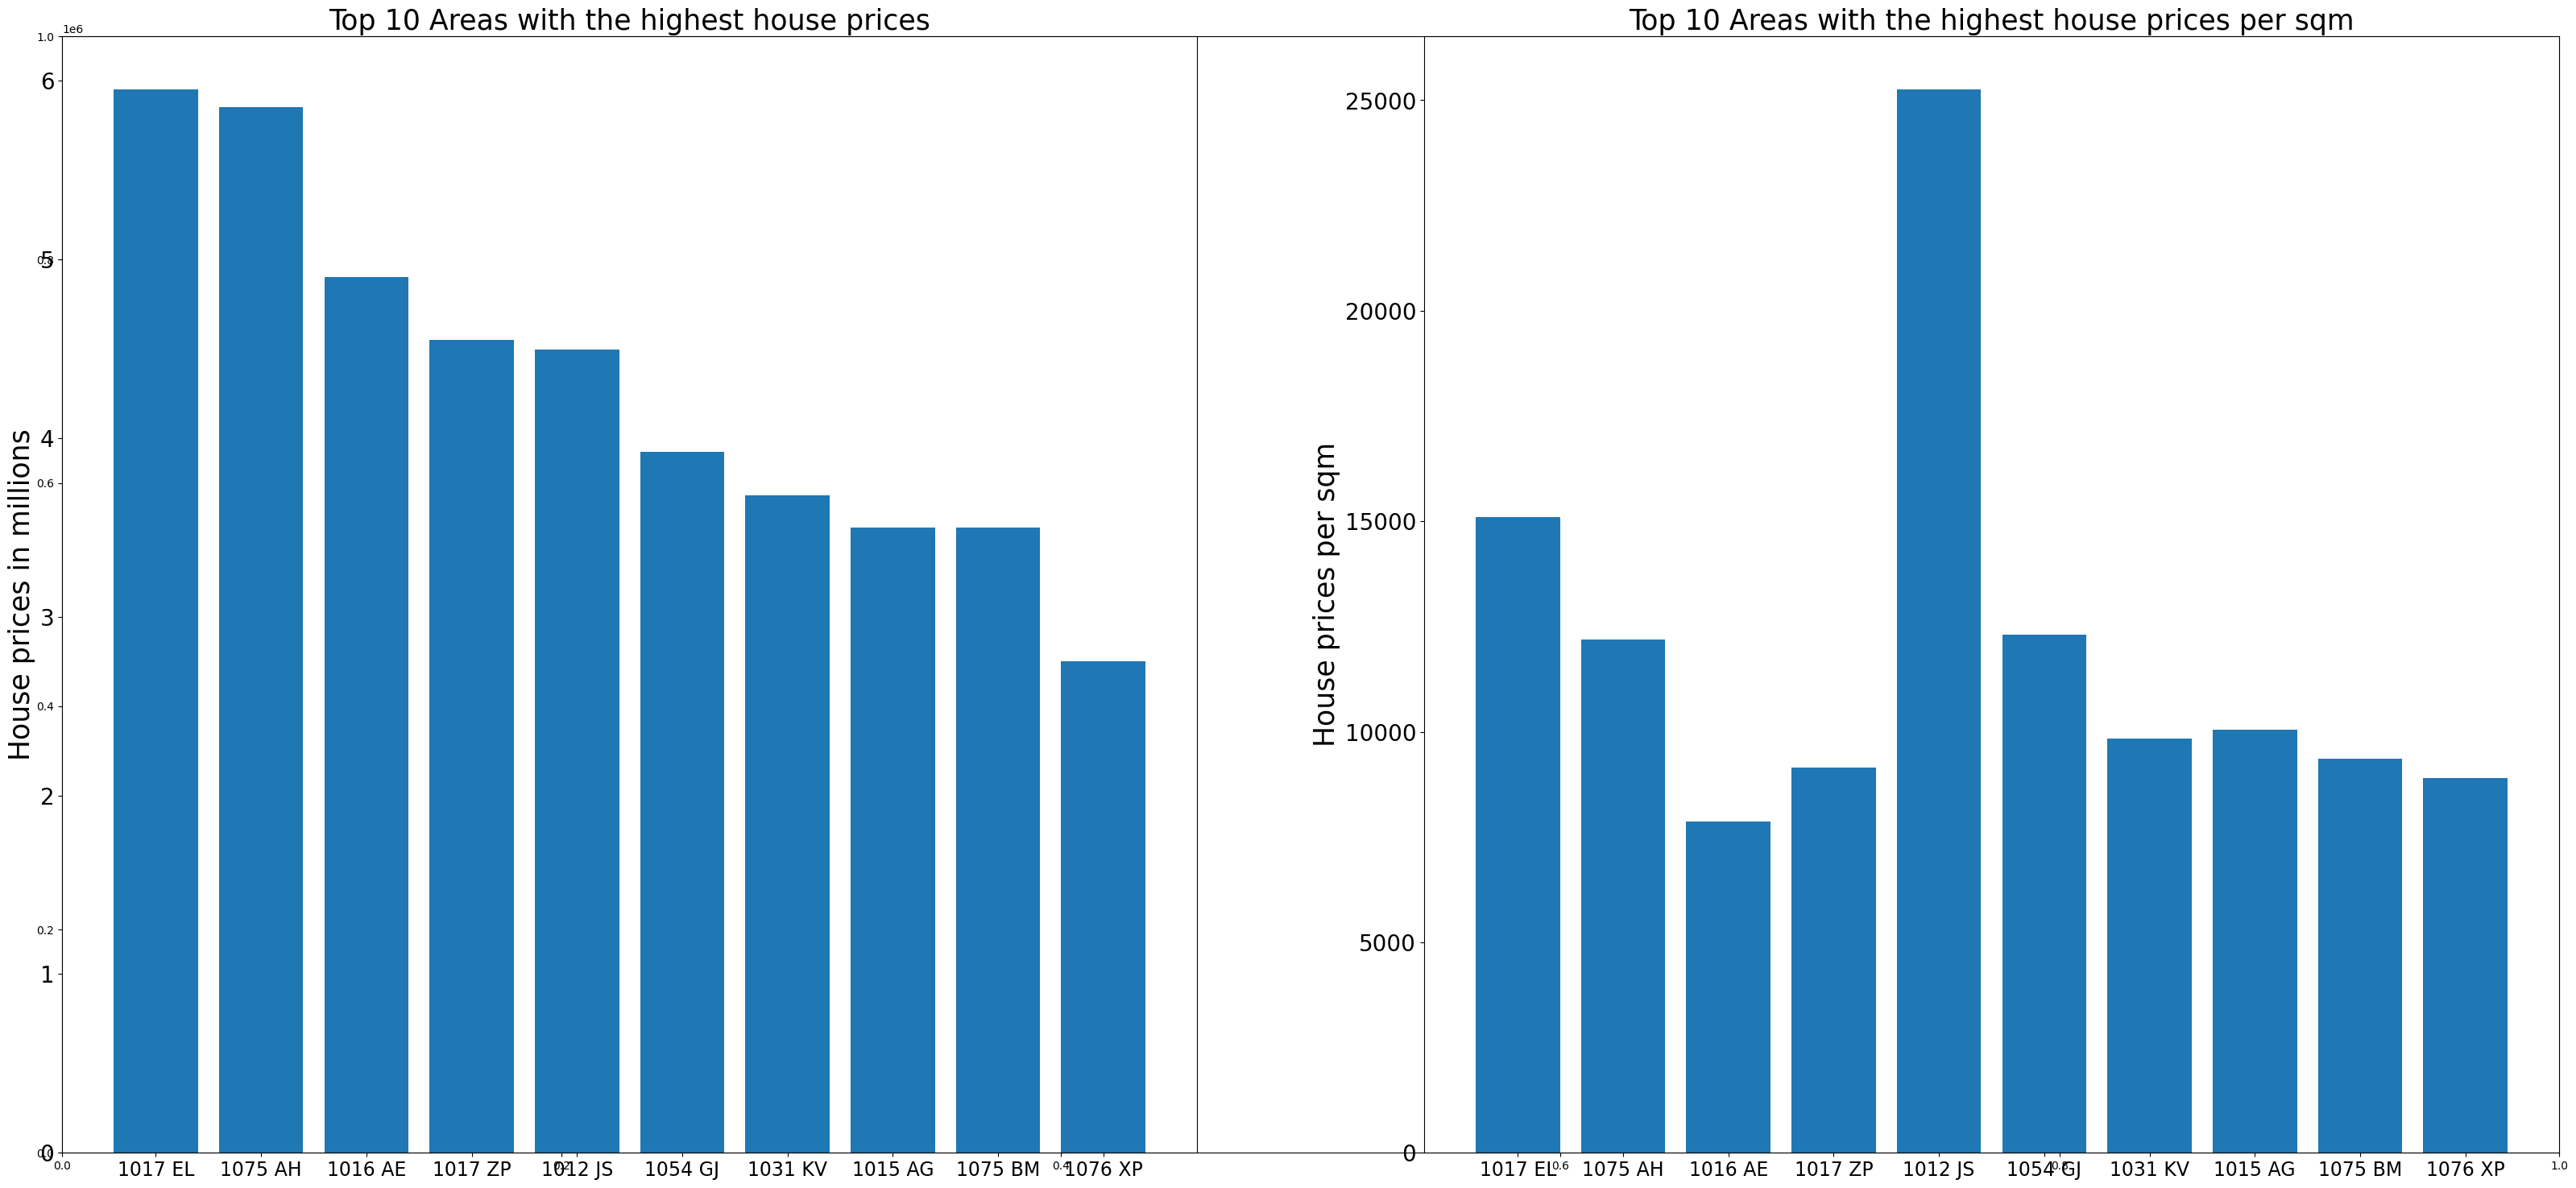

In [ ]:
houseprices_sorted = houseprices_data.sort_values('Price', ascending =
False)
houseprices_sorted.head()

# case 3: advanced 2
fig, ax = plt.subplots(figsize=(40,18))
x = houseprices_sorted['Zip'][0:10]
y = houseprices_sorted['Price'][0:10]
y1 = houseprices_sorted['PriceperSqm'][0:10]
plt.subplot(1,2,1)
plt.bar(x,y)
plt.xticks(fontsize=17)
plt.ylabel('House prices in millions', fontsize=25)
plt.yticks(fontsize=20)
plt.title('Top 10 Areas with the highest house prices',
fontsize=25)
plt.subplot(1,2,2)
plt.bar(x,y1)
plt.xticks(fontsize=17)
plt.ylabel('House prices per sqm', fontsize=25)
plt.yticks(fontsize=20)
plt.title('Top 10 Areas with the highest house prices per sqm',
fontsize=25)
plt.show()

Text(0.5, 1.0, 'Top 10 Areas with the highest price per sqm')

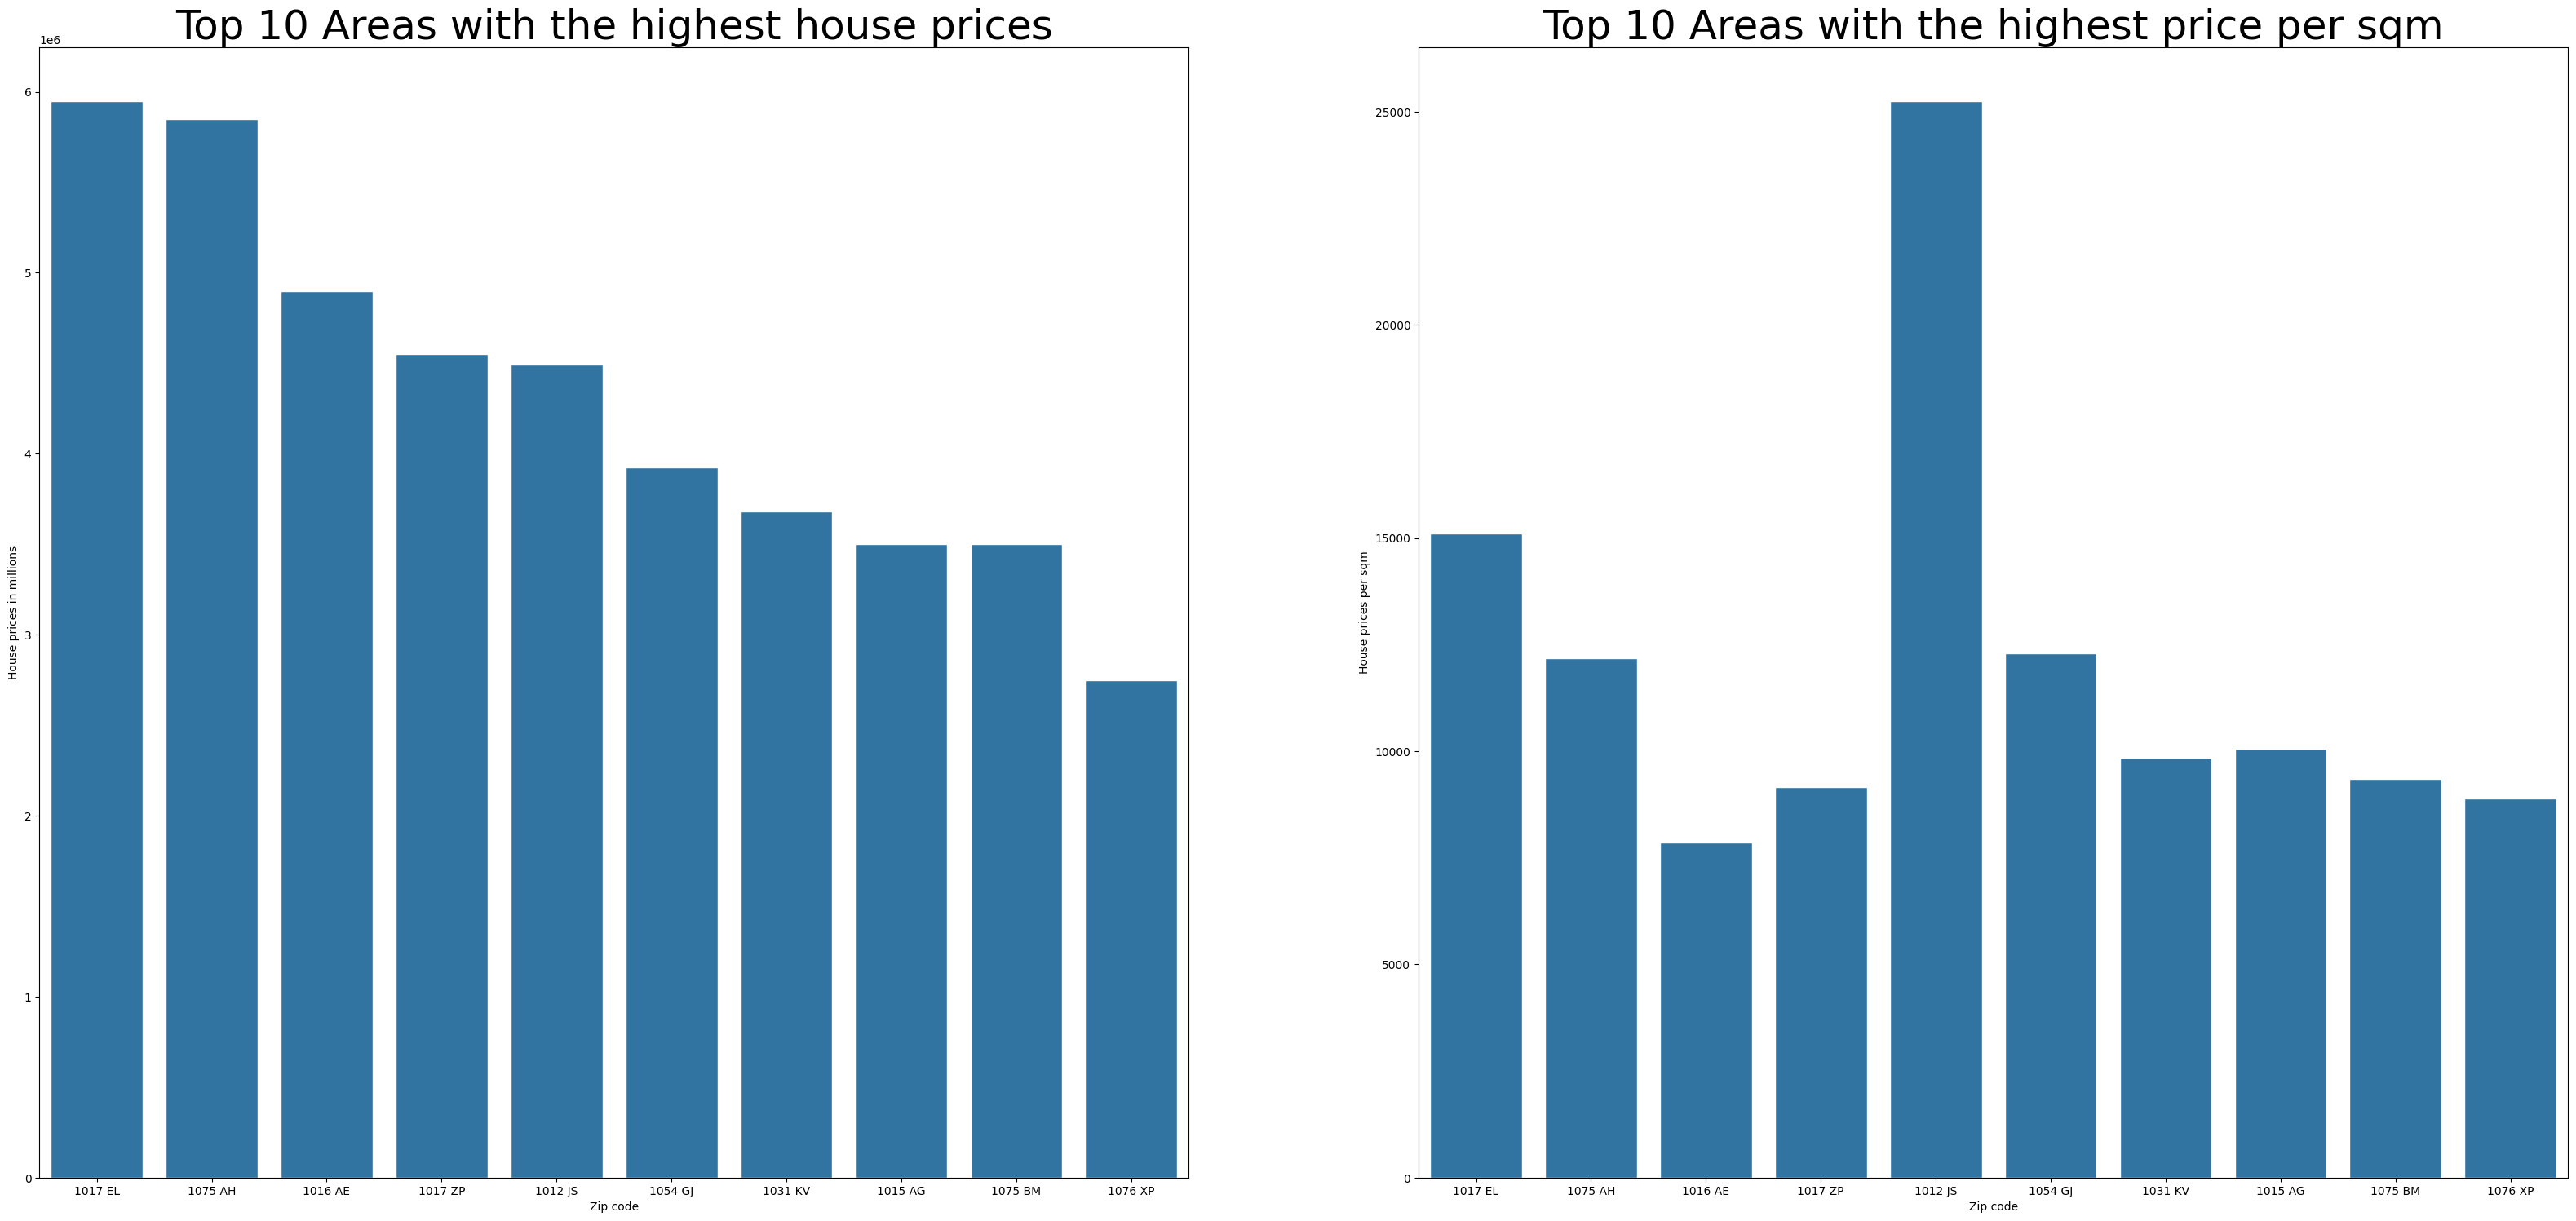

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# case 3: view multiple perspectives at once
fig, ax = plt.subplots(1, 2,figsize=(40,18))
data = houseprices_sorted[0:10]
sns.set(font_scale = 3)
ax1 = sns.barplot(data= data, x= 'Zip',y = 'Price', ax = ax[0])
ax1.set_xlabel('Zip code')
ax1.set_ylabel('House prices in millions')
ax1.set_title('Top 10 Areas with the highest house prices')
ax2 = sns.barplot(data= data, x= 'Zip',y = 'PriceperSqm',
ax=ax[1])
ax2.set_xlabel('Zip code')
ax2.set_ylabel('House prices per sqm')
ax2.set_title('Top 10 Areas with the highest price per sqm')